# PINN loss visualizer

Plotter alle losses fra `Experimenter/PINN/test_run/training_history.jsonl`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np


def find_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "Experimenter").exists() and (candidate / "SciML").exists():
            return candidate
    return start


ROOT_DIR = find_root(Path.cwd().resolve())
SPLITS = ("training", "validation", "test")
SOURCES = ("raw", "weighted")
LOSS_KEYS = ("total", "da", "eq", "ic", "bc")


def load_history(history_path: Path | str):
    history_path = Path(history_path)
    with history_path.open("r", encoding="utf-8") as f:
        return json.load(f)


def smooth(values, avg_window: int = 1):
    values = np.asarray(values, dtype=float)
    if avg_window <= 1 or values.size == 0:
        return values
    kernel = np.ones(avg_window, dtype=float) / avg_window
    return np.convolve(values, kernel, mode="same")


def plot_history(history, losses=LOSS_KEYS, avg_window: int = 1, figsize=(14, 10)):
    losses = [losses] if isinstance(losses, str) else list(losses)
    fig, axes = plt.subplots(len(SPLITS), len(SOURCES), figsize=figsize, constrained_layout=True)

    for row, split in enumerate(SPLITS):
        for col, source in enumerate(SOURCES):
            ax = axes[row, col]
            for loss in losses:
                values = smooth(history[split][source][loss], avg_window=avg_window)
                if values.size == 0:
                    continue
                steps = np.arange(1, len(values) + 1)
                ax.plot(steps, values, label=loss, alpha=0.85)

            ax.set_title(f"{split} {source}")
            ax.set_xlabel("Batches")
            ax.set_ylabel("Loss")
            ax.set_yscale("log")
            ax.grid(True)
            ax.legend()

    return fig, axes


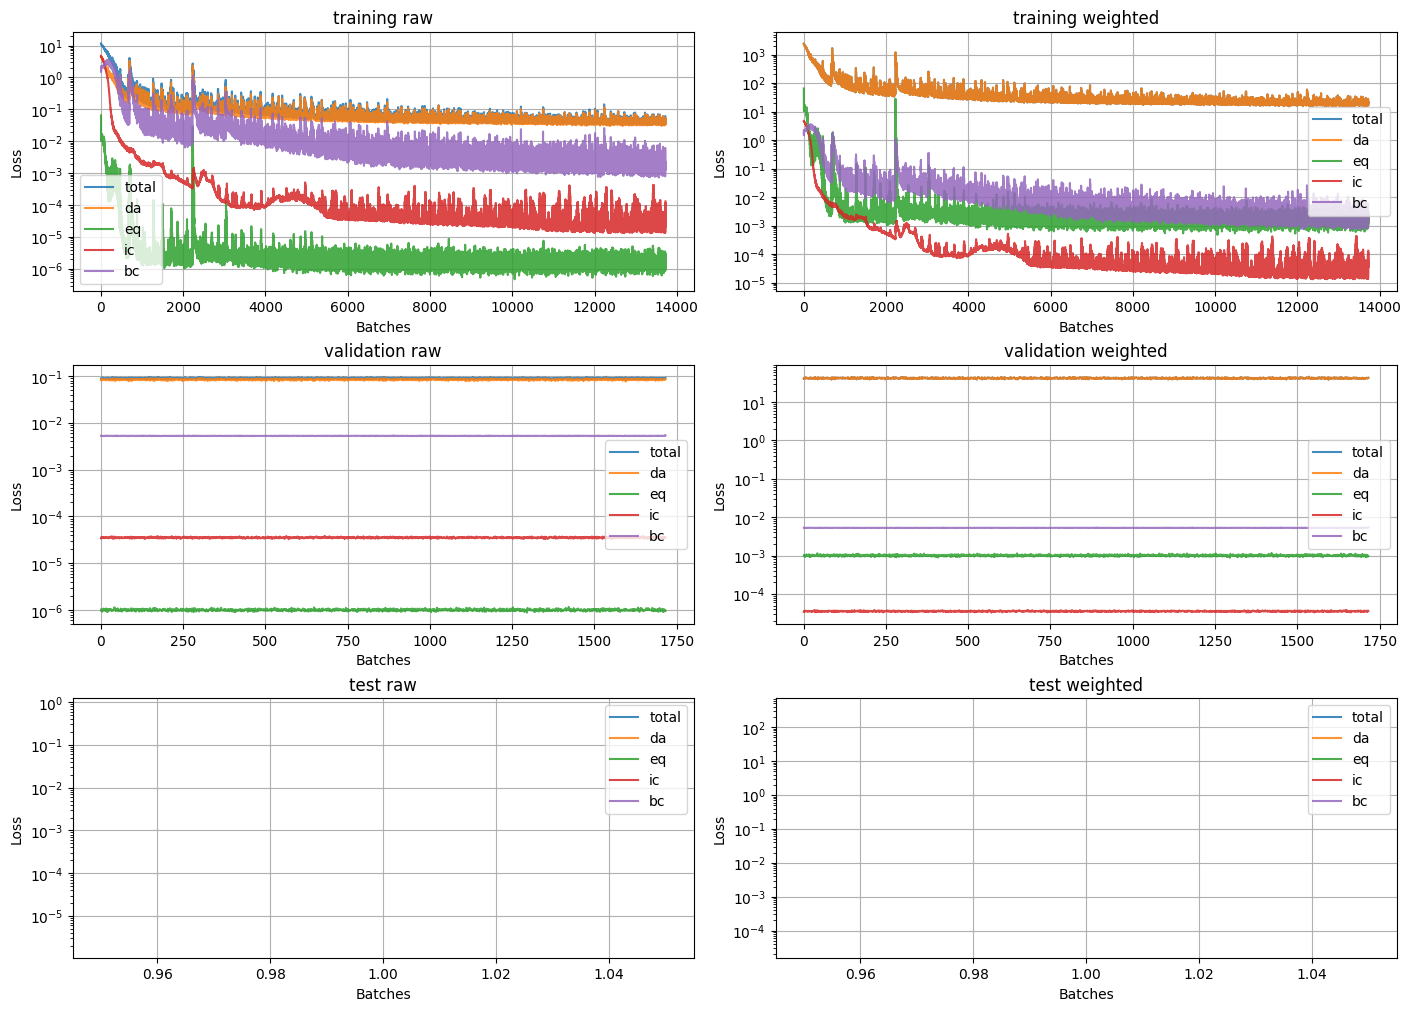

In [2]:
HISTORY_PATH = ROOT_DIR / "Experimenter" / "PINN" / "test_run" / "training_history.jsonl"
AVG_WINDOW = 1

history = load_history(HISTORY_PATH)
fig, axes = plot_history(history, losses=LOSS_KEYS, avg_window=AVG_WINDOW)
plt.show()
